In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
from parsing_library import *

/pdc/software/23.12/eb/software/anaconda3/2024.02-1-cpeGNU-23.12/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/pdc/software/23.12/eb/software/anaconda3/2024.02-1-cpeGNU-23.12/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


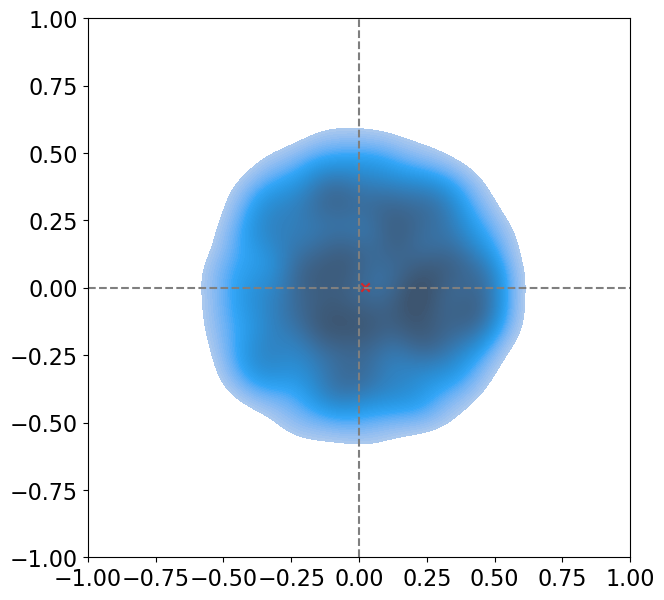

In [3]:
word_index = 1
size = 1000000
#data = '../../new_sims_jan25/ten_V100_K'
data = '../../data/ten_V100K5/1.json'
saved_fits_dir = '../../results_ten_V100K5/nofix/hmc/1'
inference_method = 'hmc'
D = 5

with open(data) as f:
    data = json.load(f)

vocabulary = data['vocabulary']


fit = load_fit_by_size(size, saved_fits_dir)
fit = {'word_vectors':fit['word_vectors'], 'context_vectors':fit['context_vectors']}

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary, D=D)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(7, 7))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-1, 1])
plt.ylim([-1, 1])


plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('')
plt.ylabel('')


#plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')




plt.show()

In [5]:
pip freeze cmdstanpy

DEPRECATION: Loading egg at /cfs/klemming/pdc/software/dardel/23.12/eb/software/anaconda3/2024.02-1-cpeGNU-23.12/lib/python3.11/site-packages/gimmik-3.2.1-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /cfs/klemming/pdc/software/dardel/23.12/eb/software/anaconda3/2024.02-1-cpeGNU-23.12/lib/python3.11/site-packages/pyfr-2.0.3-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /cfs/klemming/pdc/software/dardel/23.12/eb/software/anaconda3/2024.02-1-cpeGNU-23.12/lib/python3.11/site-packages/Mako-1.3.5-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.

/tmp/ipykernel_3177543/430581381.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(word_samples[0, :])
/pdc/software/23.12/eb/software/anaconda3/2024.02-1-cpeGNU-23.12/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Density'>

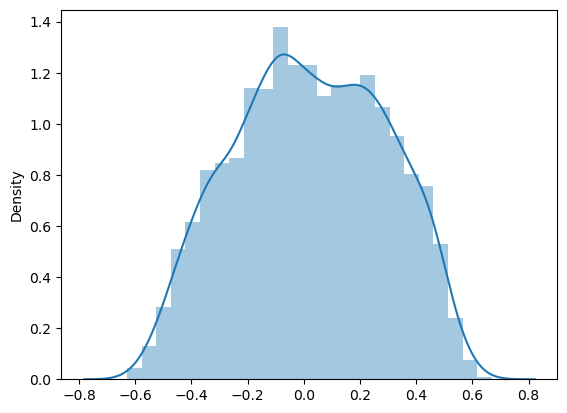

In [4]:
sns.distplot(word_samples[0, :])

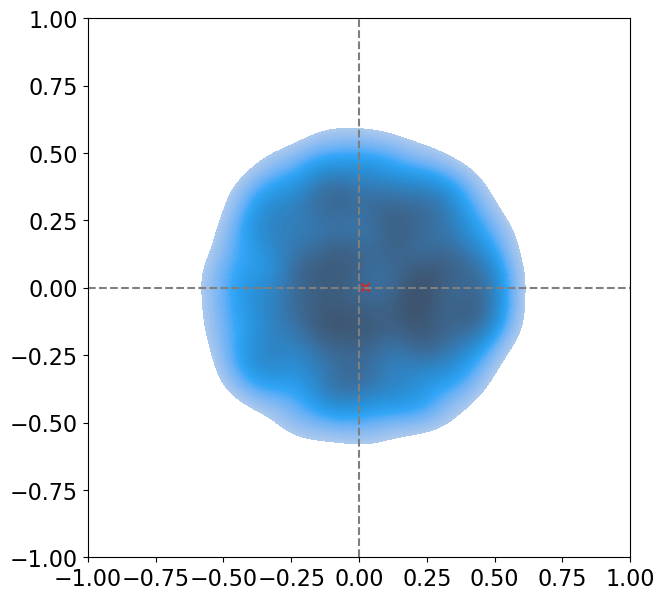